In [ ]:
pip install --upgrade igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 103.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import igraph as ig
import leidenalg as la


In [ ]:
import numpy as np
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)
def make_block_membership(n=50, sizes=(17,17,16)):
    mem = []
    for c, sz in enumerate(sizes):
        mem += [c]*sz
    mem = np.array(mem)
    assert len(mem) == n
    return mem

def nearest_psd(A, eps=1e-8):
    """
    Eigenvalue clipping projection to PSD.
    """
    A = (A + A.T) / 2.0
    w, V = np.linalg.eigh(A)
    w_clipped = np.clip(w, eps, None)
    return (V * w_clipped) @ V.T

def cov_to_corr(S):
    """
    Convert covariance-like matrix to correlation (diag=1).
    """
    d = np.sqrt(np.clip(np.diag(S), 1e-12, None))
    C = S / d[:, None] / d[None, :]
    np.fill_diagonal(C, 1.0)
    return (C + C.T) / 2.0

def make_modular_corr(n=50, membership=None, rho_in=0.35, rho_out=0.05, seed=0):
    """
    Start with a block correlation structure (dense, not thresholded).
    This is 'ground truth' correlation, before sampling noise.
    """
    #rng = np.random.default_rng(seed)
    if membership is None:
        membership = make_block_membership(n=n)
    C = np.full((n,n), rho_out, float)
    for i in range(n):
        for j in range(n):
            if membership[i] == membership[j]:
                C[i,j] = rho_in
    np.fill_diagonal(C, 1.0)
    # tiny symmetry clean-up
    C = (C + C.T)/2.0
    # ensure PSD (block matrices can still be PSD, but clipping is safe)
    C = cov_to_corr(nearest_psd(C))
    return C

def inject_negative_correlations(C_base, membership, frac_neg=0.05, mode="between",
                                neg_value=-0.15, seed=0):
    """
    Add negative correlations to a correlation matrix C_base by modifying off-diagonals.
    frac_neg is fraction of ALL possible edges (n*(n-1)/2) to set as negative.
    mode: 'within' or 'between'
    neg_value: target negative correlation to insert (e.g. -0.10 to -0.25)
    """
    #rng = np.random.default_rng(seed)
    C = np.array(C_base, float).copy()
    n = C.shape[0]
    iu = np.triu_indices(n, 1)
    possible = len(iu[0])
    n_add = int(round(frac_neg * possible))
    if n_add <= 0:
        return C

    candidates = []
    for idx in range(possible):
        i, j = iu[0][idx], iu[1][idx]
        same = (membership[i] == membership[j])
        if mode == "within" and same:
            candidates.append(idx)
        elif mode == "between" and (not same):
            candidates.append(idx)

    if len(candidates) == 0:
        return C

    n_add = min(n_add, len(candidates))
    chosen = rng.choice(candidates, size=n_add, replace=False)

    for idx in chosen:
        i, j = iu[0][idx], iu[1][idx]
        C[i,j] = neg_value
        C[j,i] = neg_value

    # project back to PSD correlation
    C = cov_to_corr(nearest_psd(C))
    return C


In [ ]:
def simulate_ar1_with_corr(C, T=1000, phi=0.7, seed=0):
    """
    Generate AR(1) multivariate Gaussian with innovation covariance proportional to C.
    For correlation structure, we set innovations ~ N(0, C) and use AR(1) recursion.
    """
    #rng = np.random.default_rng(seed)
    n = C.shape[0]
    # Cholesky of correlation (PSD)
    L = np.linalg.cholesky(C + 1e-10*np.eye(n))

    X = np.zeros((T, n), float)
    for t in range(1, T):
        eps = L @ rng.standard_normal(n)
        X[t] = phi * X[t-1] + eps
    return X


In [ ]:
def bh_fdr(pvals, q=0.05):
    p = np.asarray(pvals, float)
    m = p.size
    order = np.argsort(p)
    ranked = p[order]
    thresh = q * (np.arange(1, m+1) / m)
    passed = ranked <= thresh
    if not np.any(passed):
        return np.zeros(m, dtype=bool)
    kmax = np.max(np.where(passed)[0])
    cutoff = ranked[kmax]
    return p <= cutoff

def circular_shift_perm_pvals(X, P=200, seed=0):
    #rng = np.random.default_rng(seed)
    T, n = X.shape

    Z = X - X.mean(axis=0, keepdims=True)
    Z = Z / (Z.std(axis=0, ddof=1, keepdims=True) + 1e-12)

    C_obs = (Z.T @ Z) / (T-1)
    np.fill_diagonal(C_obs, 0.0)
    abs_obs = np.abs(C_obs)

    exceed = np.zeros((n,n), int)

    for _ in range(P):
        Zp = np.empty_like(Z)
        shifts = rng.integers(0, T, size=n)
        for j in range(n):
            Zp[:, j] = np.roll(Z[:, j], shifts[j])
        C_null = (Z.T @ Zp) / (T-1)
        np.fill_diagonal(C_null, 0.0)
        exceed += (np.abs(C_null) >= abs_obs).astype(int)

    p_mat = (exceed + 1) / (P + 1)
    np.fill_diagonal(p_mat, 1.0)
    p_mat = (p_mat + p_mat.T)/2.0
    C_obs = (C_obs + C_obs.T)/2.0
    return C_obs, p_mat

def threshold_by_fdr(C_obs, p_mat, q=0.05):
    n = C_obs.shape[0]
    iu = np.triu_indices(n, 1)
    pvals = p_mat[iu]
    keep = bh_fdr(pvals, q=q)

    W_hat = np.zeros_like(C_obs)
    W_hat[iu] = C_obs[iu] * keep
    W_hat = W_hat + W_hat.T
    np.fill_diagonal(W_hat, 0.0)
    return W_hat, int(keep.sum())


In [ ]:
import igraph as ig
import leidenalg as la

def signed_matrix_to_igraph(W_signed):
    W = np.array(W_signed, float).copy()
    np.fill_diagonal(W, 0.0)
    n = W.shape[0]
    iu = np.triu_indices(n, 1)
    w = W[iu]
    mask = w != 0
    edges = list(zip(iu[0][mask].tolist(), iu[1][mask].tolist()))
    weights = w[mask].astype(float).tolist()
    G = ig.Graph(n=n, edges=edges, directed=False)
    G.es["weight"] = weights
    return G

def leiden_signed_cpm_best(W_signed, gamma=0.1, n_seeds=15, seed0=0):
    G = signed_matrix_to_igraph(W_signed)
    best_q = -np.inf
    best_part = None
    for s in range(n_seeds):
        part = la.find_partition(
            G, la.CPMVertexPartition,
            weights="weight",
            resolution_parameter=gamma,
            seed=seed0 + s
        )
        q = part.quality()
        if q > best_q:
            best_q = q
            best_part = part
    return best_part.membership, len(best_part), best_q

def signed_modularity_gomez(W_signed, membership):
    W = np.array(W_signed, float).copy()
    np.fill_diagonal(W, 0.0)
    mem = np.array(membership)
    same = (mem[:, None] == mem[None, :]).astype(float)

    Wpos = np.where(W > 0, W, 0.0)
    Wneg = np.where(W < 0, -W, 0.0)

    s_pos = Wpos.sum(axis=1)
    s_neg = Wneg.sum(axis=1)
    m_pos = Wpos.sum() / 2.0
    m_neg = Wneg.sum() / 2.0

    Qpos = 0.0
    if m_pos > 0:
        Bpos = Wpos - np.outer(s_pos, s_pos) / (2.0 * m_pos)
        Qpos = (Bpos * same).sum() / (2.0 * m_pos)

    Qneg = 0.0
    if m_neg > 0:
        Bneg = Wneg - np.outer(s_neg, s_neg) / (2.0 * m_neg)
        Qneg = (Bneg * same).sum() / (2.0 * m_neg)

    return Qpos - Qneg


In [ ]:
import pandas as pd

def run_sim_path1(
    fracs=np.linspace(0.0, 0.10, 6),   # negatives rare
    mode="between",                    # "within" or "between"
    n_networks=30,
    n=50,
    rho_in=0.35,
    rho_out=0.05,
    neg_value=-0.15,
    T=1000,
    phi=0.7,
    P_perm=300,
    fdr_q=0.1,
    gamma_cpm=0.1,
    leiden_seeds=15,
    seed=0
):
    #rng = np.random.default_rng(seed)
    membership = make_block_membership(n=n)

    rows = []
    for frac in fracs:
        for r in range(n_networks):
            s_base = int(rng.integers(0, 2**31-1))
            s_inj  = int(rng.integers(0, 2**31-1))
            s_ts   = int(rng.integers(0, 2**31-1))
            s_perm = int(rng.integers(0, 2**31-1))
            s_lei  = int(rng.integers(0, 2**31-1))

            C0 = make_modular_corr(n=n, membership=membership, rho_in=rho_in, rho_out=rho_out, seed=s_base)
            C  = inject_negative_correlations(C0, membership, frac_neg=frac, mode=mode, neg_value=neg_value, seed=s_inj)

            X = simulate_ar1_with_corr(C, T=T, phi=phi, seed=s_ts)

            C_obs, p_mat = circular_shift_perm_pvals(X, P=P_perm, seed=s_perm)
            W_hat, n_sig = threshold_by_fdr(C_obs, p_mat, q=fdr_q)

            pos_sig = np.count_nonzero(np.triu(W_hat, 1) > 0)
            neg_sig = np.count_nonzero(np.triu(W_hat, 1) < 0)
            neg_frac_obs = neg_sig / max(1, (pos_sig + neg_sig))

            if (pos_sig + neg_sig) == 0:
                rows.append(dict(frac_neg=frac, rep=r, Q_signed=np.nan, k=np.nan,
                                 n_sig=n_sig, pos_sig=pos_sig, neg_sig=neg_sig, neg_frac_obs=neg_frac_obs))
                continue

            mem_hat, k_hat, _ = leiden_signed_cpm_best(W_hat, gamma=gamma_cpm, n_seeds=leiden_seeds, seed0=s_lei)
            Q_signed = signed_modularity_gomez(W_hat, mem_hat)

            rows.append(dict(frac_neg=frac, rep=r, Q_signed=Q_signed, k=k_hat,
                             n_sig=n_sig, pos_sig=pos_sig, neg_sig=neg_sig, neg_frac_obs=neg_frac_obs))

    return pd.DataFrame(rows)


In [ ]:
import matplotlib.pyplot as plt

def mean_sd(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return x.mean(), x.std(ddof=1)

fracs = np.linspace(0.0, 0.10, 11)

df_within = run_sim_path1(fracs=fracs, mode="within",  n_networks=25, neg_value=-0.15,
                          T=1000, P_perm=300, fdr_q=0.05, gamma_cpm=0.1, seed=1)

#df_between = run_sim_path1(fracs=fracs, mode="between", n_networks=25, neg_value=-0.18,
                           #T=1000, P_perm=300, fdr_q=0.05, gamma_cpm=0.1, seed=2)

# --- Plot signed modularity ---
def draw_plots():
  fig, ax = plt.subplots(figsize=(4.8, 3.2), dpi=300)

  for label, df in [("Negatives within communities", df_within)]:
                  #("Negatives between communities", df_between)]:
    # faint points
      for f in fracs:
          vals = df[df["frac_neg"] == f]["Q_signed"].dropna().values
          jitter = np.random.normal(0, 0.004, size=len(vals))
        #ax.scatter(np.full(len(vals), f) + jitter, vals, s=8, alpha=0.15)

      xs, ys, es = [], [], []
      for f in fracs:
          vals = df[df["frac_neg"] == f]["Q_signed"].dropna().values
          m, sd = mean_sd(vals)
          xs.append(f); ys.append(m); es.append(sd)

      ax.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3, label=label)

  ax.set_xlabel("Negative ratios on the validated FC network")
  import matplotlib.ticker as mtick
  ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  ax.set_ylabel("Modularity Q")
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
#ax.legend(frameon=False)
  plt.show()

# --- Sanity plot: observed fraction of negative significant edges ---
  fig2, ax2 = plt.subplots(figsize=(4.8, 3.0), dpi=300)

  for label, df in [("within", df_within)]:#, ("between", df_between)]:
      xs, ys, es = [], [], []
      for f in fracs:
          vals = df[df["frac_neg"] == f]["neg_frac_obs"].dropna().values
          m, sd = mean_sd(vals)
          xs.append(f); ys.append(m); es.append(sd)
      ax2.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3, label=label)

  ax2.set_xlabel("Negative ratios on the validated FC network")
  ax2.set_ylabel("Observed fraction of\nnegative significant edges")
  ax2.spines["top"].set_visible(False)
  ax2.spines["right"].set_visible(False)
  ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
#ax.legend(frameon=False, title="Negatives placed")
  plt.show()
  return fig, fig2, ax, ax2
#

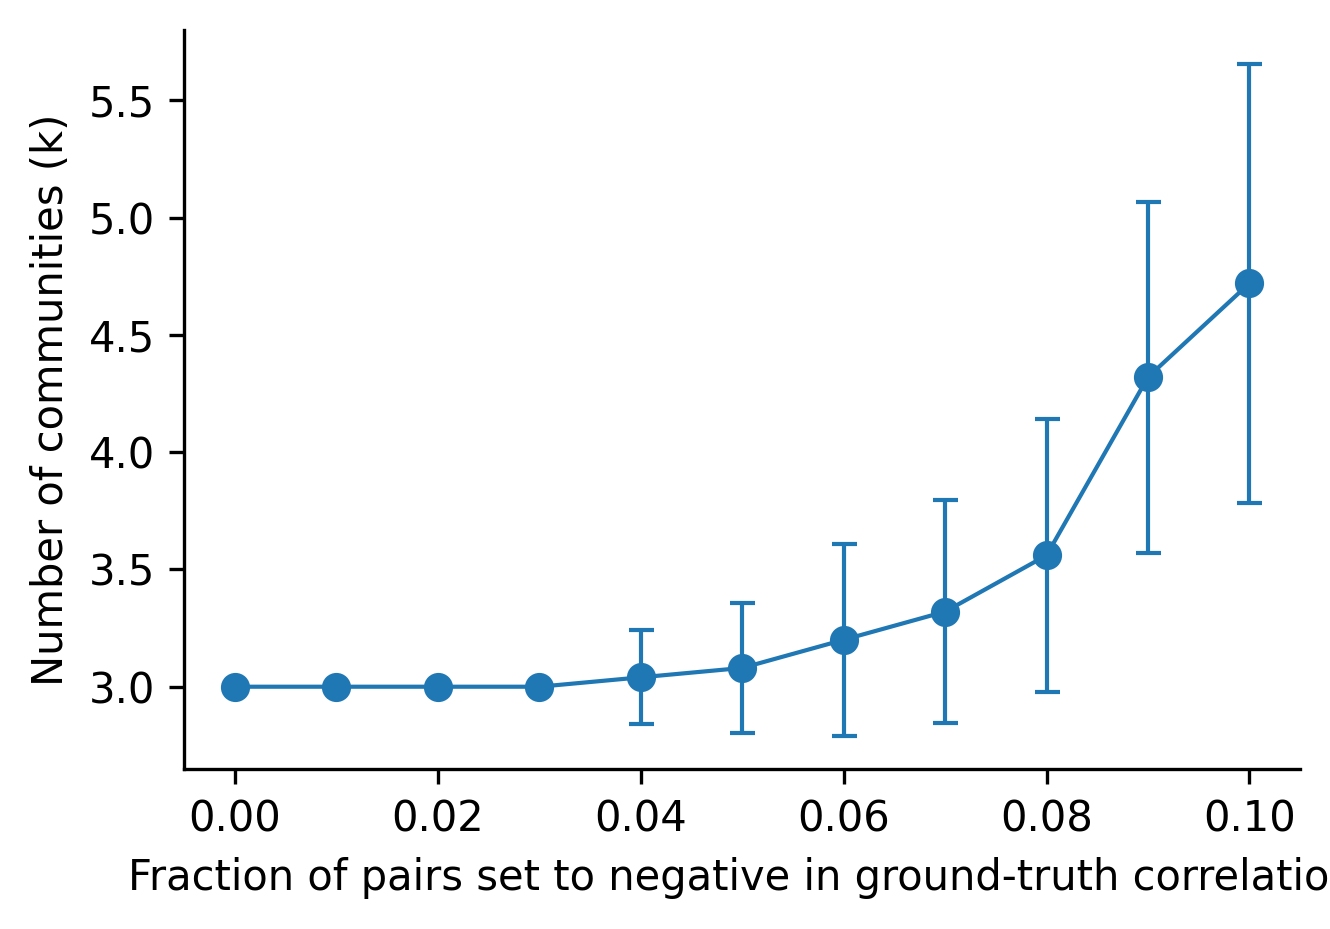

In [ ]:
fig3, ax = plt.subplots(figsize=(4.8, 3.2), dpi=300)

for label, df in [("Negatives within communities", df_within)]:
                  # ("Negatives between communities", df_between)]:

    xs, ys, es = [], [], []
    for f in fracs:
        vals = df[df["frac_neg"] == f]["k"].dropna().values
        m, sd = mean_sd(vals)
        xs.append(f); ys.append(m); es.append(sd)

    ax.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3, label=label)

ax.set_xlabel("Fraction of pairs set to negative in ground-truth correlation")
ax.set_ylabel("Number of communities (k)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.legend(frameon=False)
plt.show()


#### Now small-worldness

In [ ]:
import numpy as np
import networkx as nx

def W_to_graph(W, mode="positive"):
    """
    mode:
      - "positive": keep edges with W>0, weight=W
      - "abs": keep edges with |W|>0, weight=|W|
      - "negative_abs": keep edges with W<0, weight=|W|  (optional)
    """
    W = np.array(W, float)
    np.fill_diagonal(W, 0.0)
    n = W.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))

    iu = np.triu_indices(n, 1)
    for i, j in zip(*iu):
        w = W[i, j]
        if mode == "positive" and w > 0:
            G.add_edge(i, j, weight=float(w), distance=float(1.0 / (w + 1e-12)))
        elif mode == "abs" and w != 0:
            ww = abs(w)
            G.add_edge(i, j, weight=float(ww), distance=float(1.0 / (ww + 1e-12)))
        elif mode == "negative_abs" and w < 0:
            ww = abs(w)
            G.add_edge(i, j, weight=float(ww), distance=float(1.0 / (ww + 1e-12)))
    return G

def largest_connected_subgraph(G):
    if G.number_of_edges() == 0:
        return None
    comps = list(nx.connected_components(G))
    if len(comps) == 0:
        return None
    nodes = max(comps, key=len)
    return G.subgraph(nodes).copy()

def weighted_clustering(G):
    # NetworkX weighted clustering uses edge attribute "weight"
    return nx.average_clustering(G, weight="weight")

def weighted_char_path_length(G):
    # compute on connected graph; use "distance" as edge length
    return nx.average_shortest_path_length(G, weight="distance")
rng = np.random.default_rng(GLOBAL_SEED)
def random_reference_graph(G, seed=0, nswap_per_edge=5):
    """
    Degree-preserving randomization on the unweighted structure via double-edge swaps,
    then shuffle the weights across edges (preserve weight distribution).
    """
    #rng = np.random.default_rng(seed)

    # 1. Extract existing weights from the original graph G
    original_weights_only = [G[u][v]["weight"] for u, v in G.edges()]

    # Create a copy of the graph without attributes for the swap
    Gr_structure_only = nx.Graph(G)
    for u, v, data in Gr_structure_only.edges(data=True):
        data.clear() # Remove all attributes from edges for the swap operation

    m = Gr_structure_only.number_of_edges()
    if m < 3:
        # If there are fewer than 3 edges, just return a copy of the original graph structure
        # with its weights, as randomization might not be meaningful or possible.
        return G.copy()

    # 2. Perform degree-preserving swaps on the structure-only graph
    try:
        nx.double_edge_swap(Gr_structure_only, nswap=nswap_per_edge*m, max_tries=nswap_per_edge*m*20, seed=seed)
    except Exception:
        pass # If the swap fails, continue with the current structure

    # 3. Shuffle the extracted weights
    rng.shuffle(original_weights_only)

    # 4. Create a new graph and assign the shuffled weights to the randomized structure's edges
    Gr = nx.Graph()
    Gr.add_nodes_from(Gr_structure_only.nodes()) # Add all nodes from the randomized structure

    # Ensure the number of edges in the randomized structure matches the number of weights
    # (nx.double_edge_swap should preserve the number of edges)
    if len(original_weights_only) != Gr_structure_only.number_of_edges():
        # This should ideally not happen. If it does, there's an issue with randomization or assumptions.
        # For now, proceed, assuming it's equal.
        pass

    # Assign shuffled weights to the edges of the randomized graph structure
    for (u, v), weight in zip(Gr_structure_only.edges(), original_weights_only):
        Gr.add_edge(u, v, weight=float(weight), distance=float(1.0 / (weight + 1e-12)))

    return Gr

def small_world_metrics(W_hat, mode="positive", n_rand=20, seed=0):
    """
    Returns C, L, sigma, plus C_rand, L_rand, and size of LCC.
    """
    G = W_to_graph(W_hat, mode=mode)
    Gc = largest_connected_subgraph(G)
    if Gc is None or Gc.number_of_nodes() < 5 or Gc.number_of_edges() < 5:
        return dict(C=np.nan, L=np.nan, sigma=np.nan, C_rand=np.nan, L_rand=np.nan, n_lcc=0, m=0)

    C = weighted_clustering(Gc)
    L = weighted_char_path_length(Gc)

    Cr, Lr = [], []
    for r in range(n_rand):
        Gr = random_reference_graph(Gc, seed=seed + 1000*r)
        # ensure connected reference (if swap breaks connectivity, take LCC)
        Grc = largest_connected_subgraph(Gr)
        if Grc is None or Grc.number_of_nodes() < 5 or Grc.number_of_edges() < 5:
            continue
        Cr.append(weighted_clustering(Grc))
        Lr.append(weighted_char_path_length(Grc))

    if len(Cr) == 0 or len(Lr) == 0:
        return dict(C=C, L=L, sigma=np.nan, C_rand=np.nan, L_rand=np.nan,
                    n_lcc=Gc.number_of_nodes(), m=Gc.number_of_edges())

    C_rand = float(np.mean(Cr))
    L_rand = float(np.mean(Lr))

    sigma = (C / C_rand) / (L / L_rand) if (C_rand > 0 and L_rand > 0 and L > 0) else np.nan

    return dict(C=C, L=L, sigma=sigma, C_rand=C_rand, L_rand=L_rand,
                n_lcc=Gc.number_of_nodes(), m=Gc.number_of_edges())

In [ ]:
import pandas as pd

def run_sw_sim_path1(
    fracs=np.linspace(0.0, 0.10, 6),
    mode_inject="within",        # where negatives are inserted in ground truth: within/between
    sw_mode="positive",          # compute SW on: "positive" (recommended) or "abs"
    n_networks=25,
    n=50,
    rho_in=0.35,
    rho_out=0.05,
    neg_value=-0.18,
    T=1000,
    phi=0.7,
    P_perm=300,
    fdr_q=0.05,
    n_rand=20,
    seed=0
):
    #rng = np.random.default_rng(seed)
    rng = np.random.default_rng(GLOBAL_SEED)
    membership = make_block_membership(n=n)

    rows = []
    for frac in fracs:
        for rep in range(n_networks):
            s_base = int(rng.integers(0, 2**31-1))
            s_inj  = int(rng.integers(0, 2**31-1))
            s_ts   = int(rng.integers(0, 2**31-1))
            s_perm = int(rng.integers(0, 2**31-1))
            s_sw   = int(rng.integers(0, 2**31-1))

            C0 = make_modular_corr(n=n, membership=membership, rho_in=rho_in, rho_out=rho_out, seed=s_base)
            C  = inject_negative_correlations(C0, membership, frac_neg=frac, mode=mode_inject,
                                              neg_value=neg_value, seed=s_inj)

            X = simulate_ar1_with_corr(C, T=T, phi=phi, seed=s_ts)
            C_obs, p_mat = circular_shift_perm_pvals(X, P=P_perm, seed=s_perm)
            W_hat, n_sig = threshold_by_fdr(C_obs, p_mat, q=fdr_q)

            pos_sig = np.count_nonzero(np.triu(W_hat, 1) > 0)
            neg_sig = np.count_nonzero(np.triu(W_hat, 1) < 0)
            neg_frac_obs = neg_sig / max(1, (pos_sig + neg_sig))

            sw = small_world_metrics(W_hat, mode=sw_mode, n_rand=n_rand, seed=s_sw)

            rows.append(dict(
                frac_neg=frac, rep=rep,
                n_sig=n_sig, pos_sig=pos_sig, neg_sig=neg_sig, neg_frac_obs=neg_frac_obs,
                C=sw["C"], L=sw["L"], sigma=sw["sigma"],
                C_rand=sw["C_rand"], L_rand=sw["L_rand"],
                n_lcc=sw["n_lcc"], m_edges=sw["m"],
                inject_mode=mode_inject, sw_mode=sw_mode
            ))

    return pd.DataFrame(rows)


In [ ]:
import matplotlib.pyplot as plt

def mean_sd(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return x.mean(), x.std(ddof=1)



# Example: negatives injected within communities; compute SW on positive backbone
df_sw_between = run_sw_sim_path1(fracs=fracs, mode_inject="within", sw_mode="positive",
                                 n_networks=25, neg_value=-0.15, T=1000, P_perm=300,
                                 fdr_q=0.05, n_rand=20, seed=11)


'''
plot_metric(df_sw_within, fracs, "sigma", "Small-worldness σ")
plot_metric(df_sw_within, fracs, "C", "Weighted clustering coefficient C")
plot_metric(df_sw_within, fracs, "L", "Weighted characteristic path length L")
'''

'\nplot_metric(df_sw_within, fracs, "sigma", "Small-worldness σ")\nplot_metric(df_sw_within, fracs, "C", "Weighted clustering coefficient C")\nplot_metric(df_sw_within, fracs, "L", "Weighted characteristic path length L")\n'

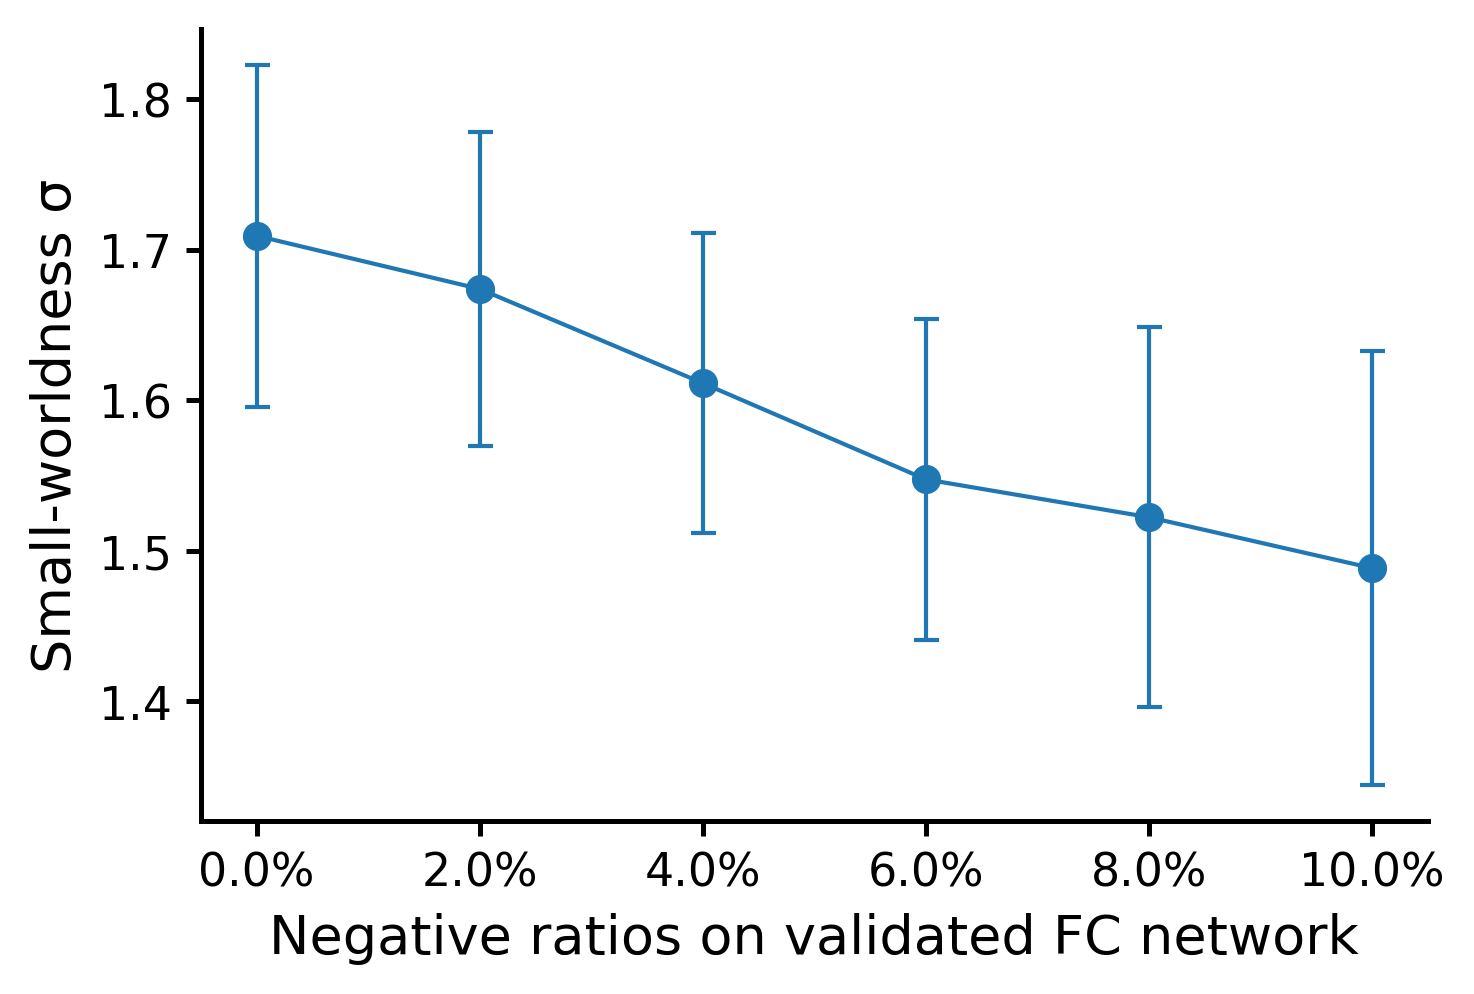

In [ ]:
plt.rcParams.update({
    "font.size": 11,                           # Base font size
    "axes.labelsize": 13,                      # Axis titles
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})
def plot_metric(df, fracs, ycol, ylabel):
    fig, ax = plt.subplots(figsize=(4.8, 3.2), dpi=300,layout='constrained')
    xs, ys, es = [], [], []
    for f in fracs:
        vals = df[df["frac_neg"] == f][ycol].dropna().values
        m, sd = mean_sd(vals)
        xs.append(f); ys.append(m); es.append(sd)
        # faint points
        jitter = np.random.normal(0, 0.004, size=len(vals))
        #ax.scatter(np.full(len(vals), f) + jitter, vals, s=8, alpha=0.15)
    ax.errorbar(xs[::-1], ys, yerr=es, marker="o", linewidth=1, capsize=3)
    ax.set_xlabel("Negative ratios on validated FC network")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    import matplotlib.ticker as mtick
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    plt.show()
    return fig, ax

fracs = np.linspace(0.0, 0.10, 6)
fig_sigma, ax = plot_metric(df_sw_between, fracs, "sigma", "Small-worldness σ")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

directory_path = '/content/drive/MyDrive/Data/deconvoluted'

from datetime import datetime
from pathlib import Path
td = datetime.today().strftime("%m_%d_%y")
FIG_DIR = Path(directory_path) / 'figures'
FIG_DIR.mkdir(parents=True,exist_ok=True)

fig_path = FIG_DIR / td

# 2. Create the directory (this returns None, so we do it on its own line)
fig_path.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [ ]:
fig_sigma.savefig(fig_path / f'sigma_{td}.svg')

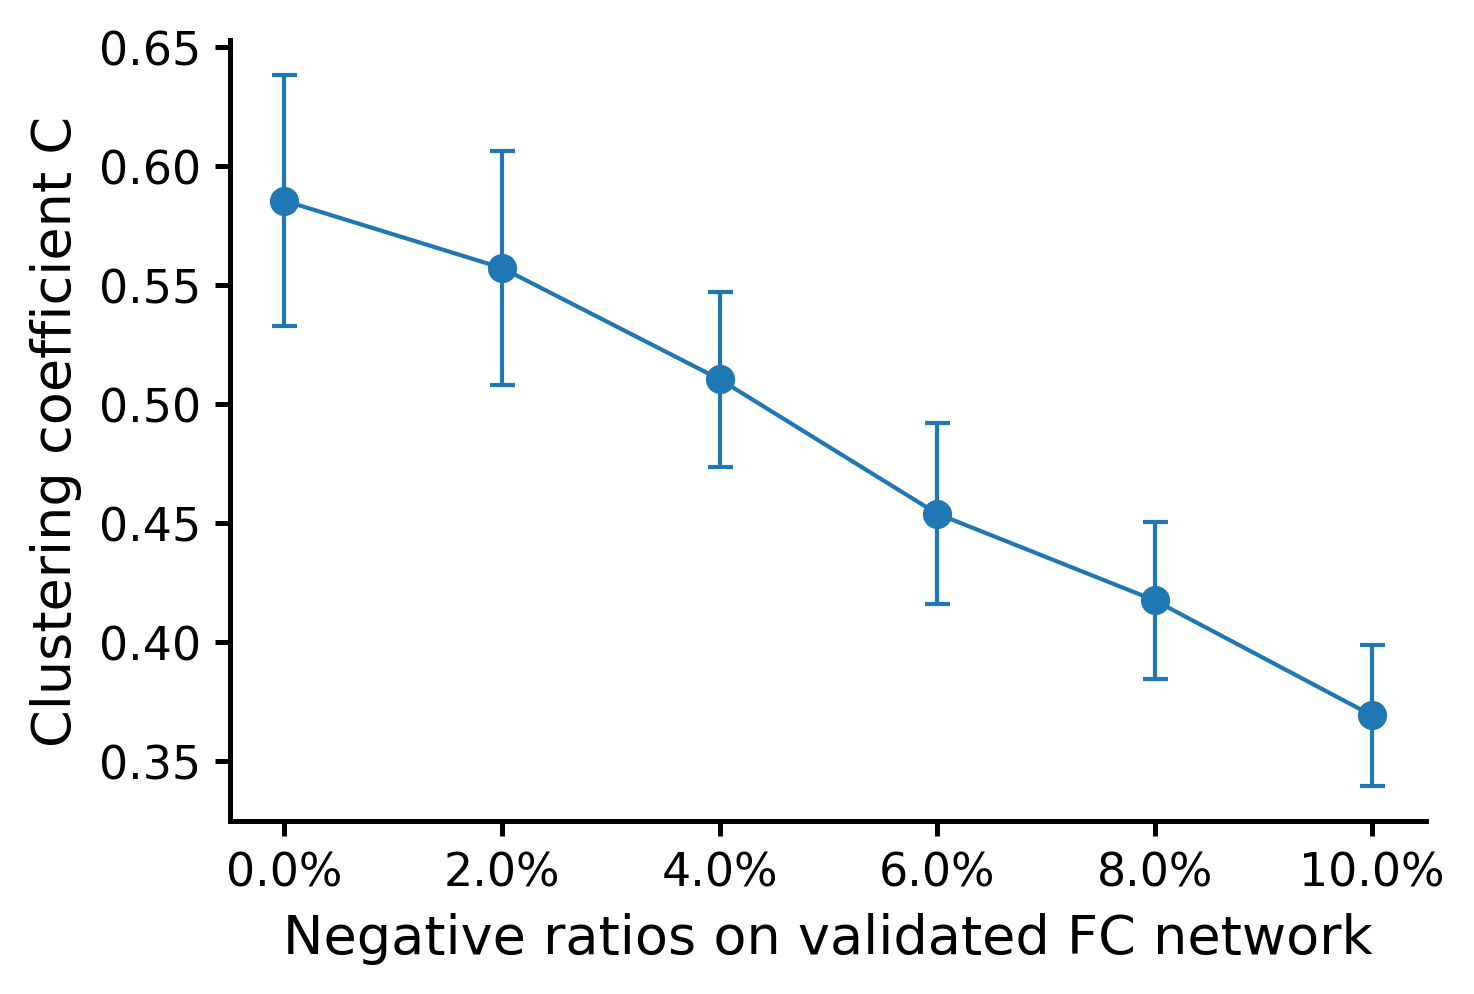

In [ ]:
#df_sw_between = run_sw_sim_path1(fracs=fracs, mode_inject="within", sw_mode="positive",
                                 #n_networks=25, neg_value=-0.15, T=1000, P_perm=300,
                                 #fdr_q=0.05, n_rand=20, seed=11)
def plot_metric(df, fracs, ycol, ylabel):
    fig, ax = plt.subplots(figsize=(4.8, 3.2), dpi=300,layout='constrained')
    xs, ys, es = [], [], []
    for f in fracs:
        vals = df[df["frac_neg"] == f][ycol].dropna().values
        m, sd = mean_sd(vals)
        xs.append(f); ys.append(m); es.append(sd)
        # faint points
        jitter = np.random.normal(0, 0.004, size=len(vals))
        #ax.scatter(np.full(len(vals), f) + jitter, vals, s=8, alpha=0.15)
    ax.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3)
    ax.set_xlabel("Negative ratios on validated FC network")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    import matplotlib.ticker as mtick
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    plt.show()
    return fig, ax
fig_c, ax = plot_metric(df_sw_between, fracs, "C", "Clustering coefficient C")

In [ ]:
fig_c.savefig(fig_path / f'c_{td}.svg')

In [ ]:
df_sw_between = run_sw_sim_path1(fracs=fracs, mode_inject="between", sw_mode="positive",
                                 n_networks=25, neg_value=-0.10, T=1000, P_perm=300,
                                 fdr_q=0.05, n_rand=20, seed=11)



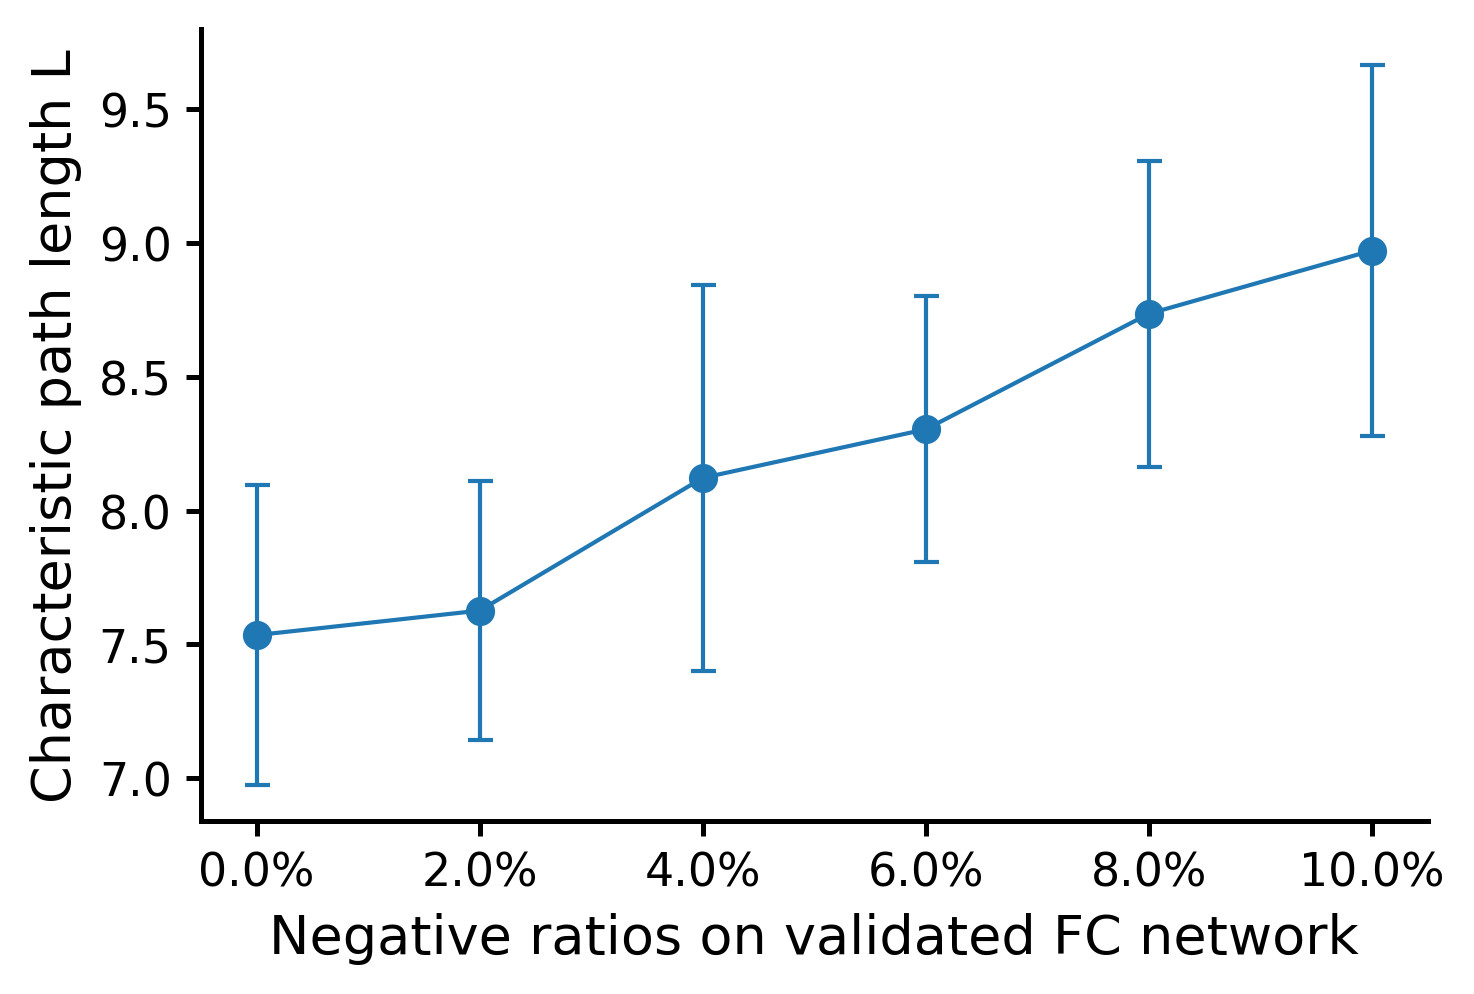

In [ ]:
fig_L, ax = plot_metric(df_sw_between, fracs, "L", "Characteristic path length L")
fig_L.savefig(fig_path / f'L_{td}.svg')

In [ ]:
df_sw_between.to_csv('df_sw_between_{td}.csv')